<a href="https://colab.research.google.com/github/Neoseb92/Modulo-1-AI/blob/main/REPO_3_A01659730.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 3 — Ozono (O₃) horario en UAM Iztapalapa (UIZ)

**Datos:** SEDEMA / Calidad del aire CDMX, archivo anual horario 2026.

Actividades:
- **a)** Contar huecos y decidir cómo tratarlos
- **b)** Graficar la serie y su ACF hasta 72 h
- **c)** Correr ADF y KPSS
- **d)** Restar la media de cada hora del día y repetir c)
- **e)** Restar la media de cada mes × hora y repetir c)
- **f)** Diferencia de 24 h, repetir c) y comparar ACF y varianza con e)

In [3]:
import io, gzip, zipfile, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss, acf
from statsmodels.graphics.tsaplots import plot_acf
import warnings
warnings.filterwarnings("ignore")  # KPSS avisa cuando el p-valor sale de su tabla (0.01–0.10)

plt.rcParams["figure.figsize"] = (12, 4)
URL = "https://aire.cdmx.gob.mx/descargas/Opendata/anuales_horarios_gz/contaminantes_2026.csv.gz"
ESTACION, PARAMETRO = "UIZ", "O3"

## 0. Carga de datos



In [4]:
RUTA_LOCAL = "contaminantes_2026.csv.gz"  # pon None para descargar desde la URL

def leer_crudo():
    if RUTA_LOCAL:
        with open(RUTA_LOCAL, "rb") as f:
            raw = f.read()
    else:
        req = urllib.request.Request(URL, headers={"User-Agent": "Mozilla/5.0"})
        raw = urllib.request.urlopen(req, timeout=60).read()
    if raw[:2] == b"\x1f\x8b":                 # gzip
        raw = gzip.decompress(raw)
    elif raw[:2] == b"PK":                     # zip (algunos navegadores lo re-empaquetan)
        import zipfile
        with zipfile.ZipFile(io.BytesIO(raw)) as z:
            raw = z.read(z.namelist()[0])
    texto = raw.decode("latin-1")
    lineas = texto.splitlines()
    inicio = next(i for i, l in enumerate(lineas) if "id_station" in l.lower())
    return pd.read_csv(io.StringIO("\n".join(lineas[inicio:])))

df = leer_crudo()
df.columns = [c.strip().lower() for c in df.columns]
print(df.shape)
df.head()

(1556928, 5)


,date,id_station,id_parameter,valor,unit
0,2026-01-01 00:00:00,ACO,CO,NaN,15
1,2026-01-01 00:00:00,ACO,NO,NaN,1
2,2026-01-01 00:00:00,ACO,NO2,NaN,1
3,2026-01-01 00:00:00,ACO,NOX,NaN,1
4,2026-01-01 00:00:00,ACO,O3,NaN,1


In [5]:
def parsear_fecha(s):
    if s.iloc[0][4] == "-":                      # formato ISO: 2026-01-01 00:00:00
        return pd.to_datetime(s, format="%Y-%m-%d %H:%M:%S")
    # formato viejo: "dd/mm/yyyy HH:MM" con HH en 1..24
    partes = s.str.split(" ", n=1, expand=True)
    fecha, hora = partes[0], partes[1]
    h = hora.str.split(":").str[0].astype(int)
    return pd.to_datetime(fecha, format="%d/%m/%Y") + pd.to_timedelta(h, unit="h")

o3 = df[(df["id_station"].str.strip() == ESTACION) & (df["id_parameter"].str.strip() == PARAMETRO)].copy()
o3["fecha"] = parsear_fecha(o3["date"].astype(str).str.strip())
col_val = "valor" if "valor" in o3 else "value"
o3["value"] = pd.to_numeric(o3[col_val], errors="coerce").replace(-99, np.nan)
o3.loc[o3["value"] < 0, "value"] = np.nan

serie = o3.set_index("fecha")["value"].sort_index()
serie = serie[~serie.index.duplicated()]
print("Unidad:", o3["unit"].iloc[0] if "unit" in o3 else "?")
print("Rango:", serie.index.min(), "→", serie.index.max())

Unidad: 1
Rango: 2026-01-01 00:00:00 → 2026-07-31 23:00:00


## a) Conteo de huecos



In [6]:
idx_completo = pd.date_range(serie.index.min(), serie.index.max(), freq="h")
faltan_filas = len(idx_completo) - len(serie)
y = serie.reindex(idx_completo)
y.index.name = "fecha"

n_nan = int(y.isna().sum())
print(f"Horas esperadas : {len(y)}")
print(f"Filas ausentes  : {faltan_filas}")
print(f"Total de huecos : {n_nan}  ({100*n_nan/len(y):.2f} %)")

# Longitud de cada racha de huecos
es_nan = y.isna()
grupos = (es_nan != es_nan.shift()).cumsum()
rachas = es_nan.groupby(grupos).sum()
rachas = rachas[rachas > 0].astype(int)
print(f"\nNúmero de rachas: {len(rachas)}")
print(rachas.value_counts().sort_index().rename("n_rachas").to_frame().T)

Horas esperadas : 5088
Filas ausentes  : 0
Total de huecos : 228  (4.48 %)

Número de rachas: 68
value     1   2   3   4   5   6   8   49
n_rachas  19   3  33   9   1   1   1   1


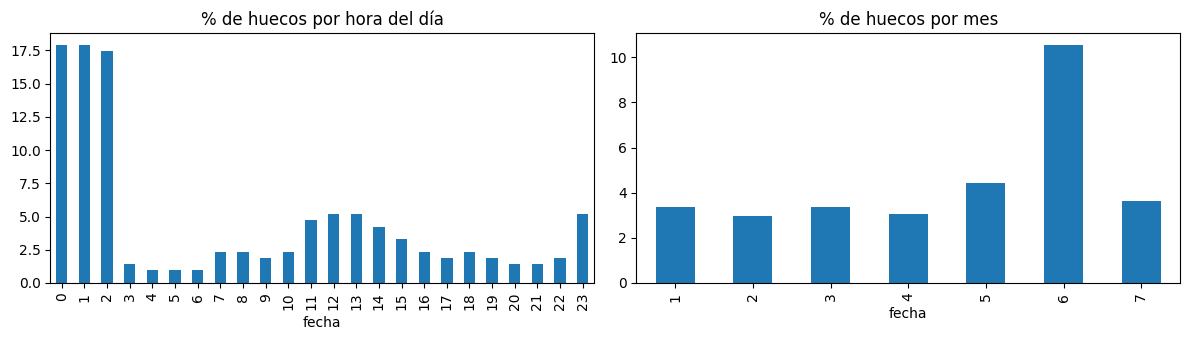

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
y.isna().groupby(y.index.hour).mean().mul(100).plot.bar(ax=ax[0], title="% de huecos por hora del día")
y.isna().groupby(y.index.month).mean().mul(100).plot.bar(ax=ax[1], title="% de huecos por mes")
plt.tight_layout(); plt.show()

### Decisión de tratamiento

- **Huecos cortos (≤ 3 h):** interpolación lineal en el tiempo. El ozono cambia suave de una hora a la siguiente, así que la recta entre vecinos es razonable.
- **Huecos largos (> 3 h):** interpolar en línea recta borraría el ciclo diario (el pico de la tarde). Los rellenamos con el **perfil climatológico mes × hora**, es decir, la media de esa hora en ese mes.
- No eliminamos filas: ADF, KPSS y la ACF suponen una malla temporal **regular**, y borrar horas desplazaría los rezagos (el rezago 24 dejaría de ser "el mismo momento ayer").

> Ajusta `MAX_INTERP` si en clase acordaron otro umbral.

In [8]:
MAX_INTERP = 3

# máscara de huecos cortos (racha ≤ MAX_INTERP)
largo_racha = es_nan.groupby(grupos).transform("sum")
corto = es_nan & (largo_racha <= MAX_INTERP)

y_lin = y.interpolate(method="time", limit_area="inside")
yf = y.copy()
yf[corto] = y_lin[corto]

clim_mh = y.groupby([y.index.month, y.index.hour]).transform("mean")
yf = yf.fillna(clim_mh)
yf = yf.interpolate(limit_direction="both")   # por si quedara algún borde

print("Huecos restantes:", int(yf.isna().sum()))
print(f"Rellenos por interpolación: {int(corto.sum())} | por climatología: {int((es_nan & ~corto).sum())}")

Huecos restantes: 0
Rellenos por interpolación: 124 | por climatología: 104


## b) Serie y ACF hasta 72 h

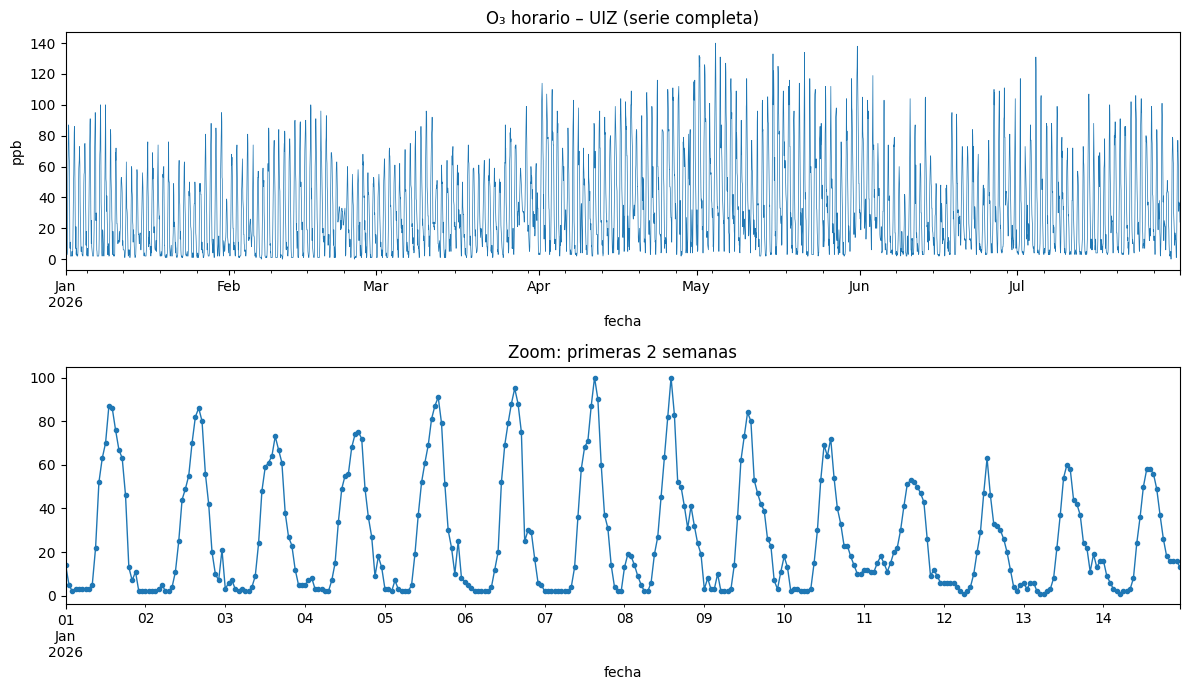

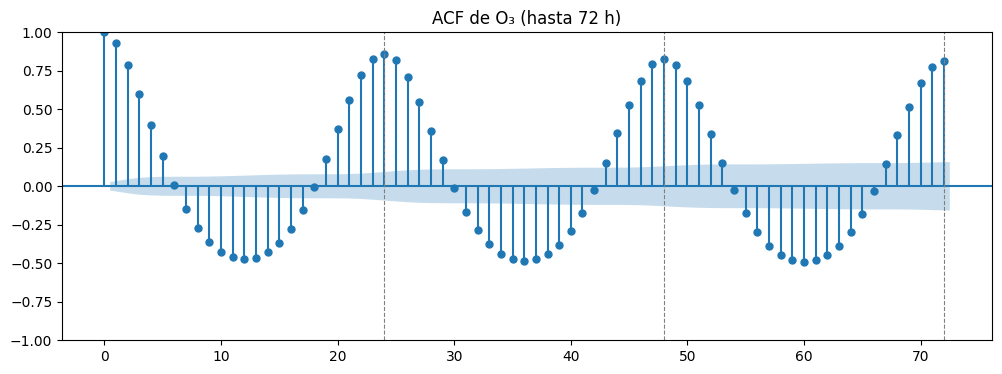

In [9]:
fig, ax = plt.subplots(2, 1, figsize=(12, 7))
yf.plot(ax=ax[0], lw=0.5, title="O₃ horario – UIZ (serie completa)")
ax[0].set_ylabel("ppb")
yf.iloc[:24*14].plot(ax=ax[1], lw=1, marker=".", title="Zoom: primeras 2 semanas")
plt.tight_layout(); plt.show()

plot_acf(yf, lags=72, title="ACF de O₃ (hasta 72 h)")
for k in (24, 48, 72): plt.axvline(k, ls="--", c="gray", lw=0.8)
plt.show()

**Lectura esperada:** la ACF oscila con periodo de **24 h** (picos en 24, 48, 72) y decae muy lento.
Ese patrón indica **estacionalidad diaria**: el ozono se forma con la luz del sol, así que sube cada tarde y baja cada noche.

## c) Pruebas ADF y KPSS



In [10]:
def pruebas(x, nombre, lags_adf=48):
    x = pd.Series(x).dropna()
    adf_stat, adf_p, *_ = adfuller(x, maxlag=lags_adf, autolag="AIC")
    kpss_stat, kpss_p, *_ = kpss(x, regression="c", nlags="auto")
    if adf_p < 0.05 and kpss_p >= 0.05:   veredicto = "Estacionaria"
    elif adf_p >= 0.05 and kpss_p < 0.05: veredicto = "No estacionaria"
    elif adf_p < 0.05 and kpss_p < 0.05:  veredicto = "Mixto (ADF sí, KPSS no)"
    else:                                  veredicto = "Inconcluso"
    return {"serie": nombre, "ADF stat": adf_stat, "ADF p": adf_p,
            "KPSS stat": kpss_stat, "KPSS p": kpss_p, "veredicto": veredicto,
            "varianza": x.var()}

resultados = [pruebas(yf, "c) original")]
pd.DataFrame(resultados).round(4)

,serie,ADF stat,ADF p,KPSS stat,KPSS p,veredicto,varianza
0,c) original,-4.2145,0.0006,2.5408,0.01,"Mixto (ADF sí, KPSS no)",845.5805


> **Nota:** `maxlag=48` en ADF deja que la regresión "vea" al menos dos ciclos diarios; con muy pocos rezagos la estacionalidad contamina el resultado.
> El p-valor de KPSS sale truncado a 0.01 o 0.10 cuando el estadístico se sale de su tabla; por eso se apagaron los warnings.

## d) Restar la media de cada hora del día

Calculamos el perfil diario promedio (24 valores, uno por hora) y lo restamos.
Esto quita el ciclo diario "típico" del año, pero no cambia con la época del año.

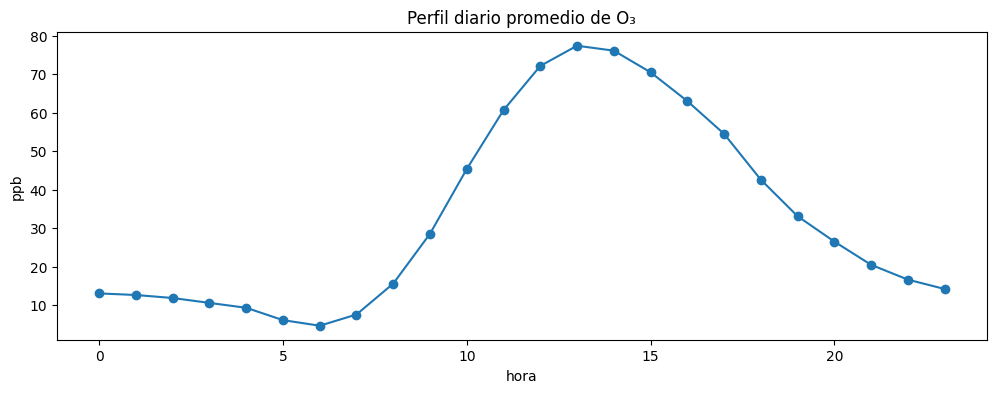

,serie,ADF stat,ADF p,KPSS stat,KPSS p,veredicto,varianza
0,c) original,-4.2145,0.0006,2.5408,0.01,"Mixto (ADF sí, KPSS no)",845.5805
1,d) − media por hora,-4.5531,0.0002,2.7120,0.01,"Mixto (ADF sí, KPSS no)",229.2292


In [11]:
media_hora = yf.groupby(yf.index.hour).transform("mean")
y_d = yf - media_hora

yf.groupby(yf.index.hour).mean().plot(marker="o", title="Perfil diario promedio de O₃")
plt.xlabel("hora"); plt.ylabel("ppb"); plt.show()

resultados.append(pruebas(y_d, "d) − media por hora"))
pd.DataFrame(resultados).round(4)

## e) Restar la media de cada mes × hora



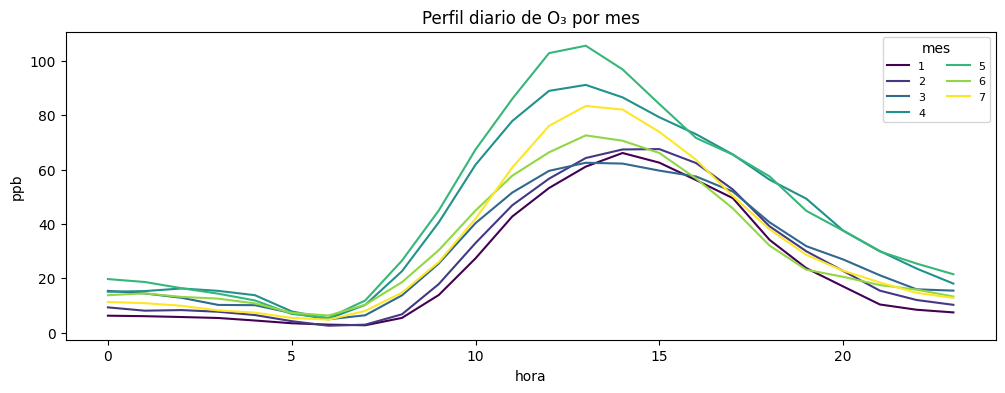

,serie,ADF stat,ADF p,KPSS stat,KPSS p,veredicto,varianza
0,c) original,-4.2145,0.0006,2.5408,0.01,"Mixto (ADF sí, KPSS no)",845.5805
1,d) − media por hora,-4.5531,0.0002,2.7120,0.01,"Mixto (ADF sí, KPSS no)",229.2292
2,e) − media mes×hora,-7.6572,0.0000,0.0528,0.10,Estacionaria,153.1312


In [12]:
media_mh = yf.groupby([yf.index.month, yf.index.hour]).transform("mean")
y_e = yf - media_mh

perfil = yf.groupby([yf.index.hour, yf.index.month]).mean().unstack()
perfil.plot(title="Perfil diario de O₃ por mes", cmap="viridis")
plt.xlabel("hora"); plt.ylabel("ppb"); plt.legend(title="mes", ncol=2, fontsize=8); plt.show()

resultados.append(pruebas(y_e, "e) − media mes×hora"))
pd.DataFrame(resultados).round(4)

## f) Diferencia de 24 h



Compara cada hora con la misma hora de ayer. Elimina el ciclo diario **sin estimar ninguna media**,
pero se pierden las primeras 24 observaciones.

In [13]:
y_f = yf.diff(24).dropna()
resultados.append(pruebas(y_f, "f) diferencia 24 h"))
tabla = pd.DataFrame(resultados).set_index("serie").round(4)
tabla

,ADF stat,ADF p,KPSS stat,KPSS p,veredicto,varianza
serie,,,,,,
c) original,-4.2145,0.0006,2.5408,0.01,"Mixto (ADF sí, KPSS no)",845.5805
d) − media por hora,-4.5531,0.0002,2.7120,0.01,"Mixto (ADF sí, KPSS no)",229.2292
e) − media mes×hora,-7.6572,0.0000,0.0528,0.10,Estacionaria,153.1312
f) diferencia 24 h,-11.8881,0.0000,0.0097,0.10,Estacionaria,228.6656


### Comparación de ACF y varianza: e) vs f)

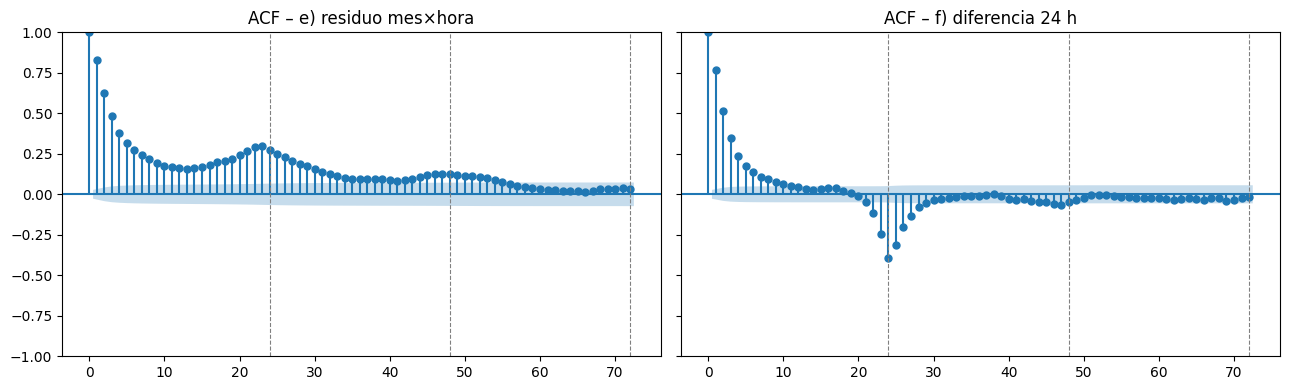

,e) mes×hora,f) dif 24 h,razón f/e
varianza,153.131,228.666,1.49
ACF lag 1,0.828,0.770,0.93
ACF lag 24,0.271,-0.395,-1.46
ACF lag 48,0.124,-0.049,-0.40
ACF lag 72,0.032,-0.016,-0.50


In [14]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
plot_acf(y_e, lags=72, ax=ax[0], title="ACF – e) residuo mes×hora")
plot_acf(y_f, lags=72, ax=ax[1], title="ACF – f) diferencia 24 h")
for a in ax:
    for k in (24, 48, 72): a.axvline(k, ls="--", c="gray", lw=0.8)
plt.tight_layout(); plt.show()

acf_e = acf(y_e, nlags=72); acf_f = acf(y_f, nlags=72)
comp = pd.DataFrame({
    "e) mes×hora": [y_e.var(), acf_e[1], acf_e[24], acf_e[48], acf_e[72]],
    "f) dif 24 h": [y_f.var(), acf_f[1], acf_f[24], acf_f[48], acf_f[72]],
}, index=["varianza", "ACF lag 1", "ACF lag 24", "ACF lag 48", "ACF lag 72"]).round(3)
comp["razón f/e"] = (comp["f) dif 24 h"] / comp["e) mes×hora"]).round(2)
comp

### Interpretación (datos reales UIZ, ene–jul 2026)

**Huecos (a).** Hay 228 horas faltantes (4.5 %) repartidas en 68 rachas. La mayoría duran 1–3 h, pero hay una racha de **49 h**. Los 124 huecos cortos se interpolaron y los 104 de rachas largas se rellenaron con la climatología mes × hora.

**Pruebas (c–f).**
- **Original y d):** ADF rechaza la raíz unitaria, pero KPSS rechaza estacionariedad (p = 0.01). El resultado es **mixto**: no hay raíz unitaria, pero el nivel no es constante. Quitar solo el perfil diario (d) deja intacto el cambio de nivel entre meses, porque la temporada de ozono (mar–may) es más alta.
- **e) y f):** las dos pasan ambas pruebas → **estacionarias**.

**Varianza.** Original 846 → d) 229 → e) **153** → f) **229**. La diferencia de 24 h tiene **1.49×** la varianza de e). Esto concuerda con la teoría:
$\operatorname{Var}(u_t-u_{t-24}) = 2\sigma^2(1-\rho_{24}) = 2(1-0.271)\sigma^2 \approx 1.46\,\sigma^2$.
Restar el día anterior suma el ruido de dos días; solo se cancela la parte que está correlacionada.

**ACF.**
- **e)** mantiene ρ₂₄ = +0.27 y ρ₄₈ = +0.12. Queda algo de ciclo diario que la media mensual no captura, porque el pico cambia de un día a otro según el clima.
- **f)** cambia ese valor a **ρ₂₄ = −0.40**. Es la huella típica de la diferencia estacional: introduce un término MA(24) negativo (para ruido blanco sería −0.5).

**Conclusión.** e) deja una serie con menos varianza y una estacionalidad residual pequeña y positiva. f) elimina el ciclo sin estimar medias, pero infla la varianza ~50 % y crea una autocorrelación negativa en 24 h que habría que modelar. En un SARIMA, eso corresponde a usar D = 1 con s = 24 y un término MA estacional.

In [15]:
print(tabla[["ADF p", "KPSS p", "veredicto", "varianza"]])

                      ADF p  KPSS p                veredicto  varianza
serie                                                                 
c) original          0.0006    0.01  Mixto (ADF sí, KPSS no)  845.5805
d) − media por hora  0.0002    0.01  Mixto (ADF sí, KPSS no)  229.2292
e) − media mes×hora  0.0000    0.10             Estacionaria  153.1312
f) diferencia 24 h   0.0000    0.10             Estacionaria  228.6656
